In [1]:
### 1. Mount Google Drive ###

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
### 2. Install Ultralytics ###

!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.4 MB/s eta 0:00:00


In [8]:
### 3. Train model ###

import os

from ultralytics import YOLO


# Load a model
model = YOLO('yolo11n-cls.pt')  # load a pretained model

# Use the model
results = model.train(data='/content/drive/MyDrive/CS440/Drones Group Project 1 Photos/Jeep_Kia_Volkswagon_Dataset', epochs=30)  # train the model


Ultralytics 8.3.206 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/CS440/Drones Group Project 1 Photos/Jeep_Kia_Volkswagon_Dataset, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ove

In [9]:
### 4. Copy results ###

!scp -r /content/runs '/content/drive/MyDrive/CS440/Drones Group Project 1 Photos/Jeep_Kia_Volkswagon_Dataset'

# Inference

In [10]:
from IPython.display import Image

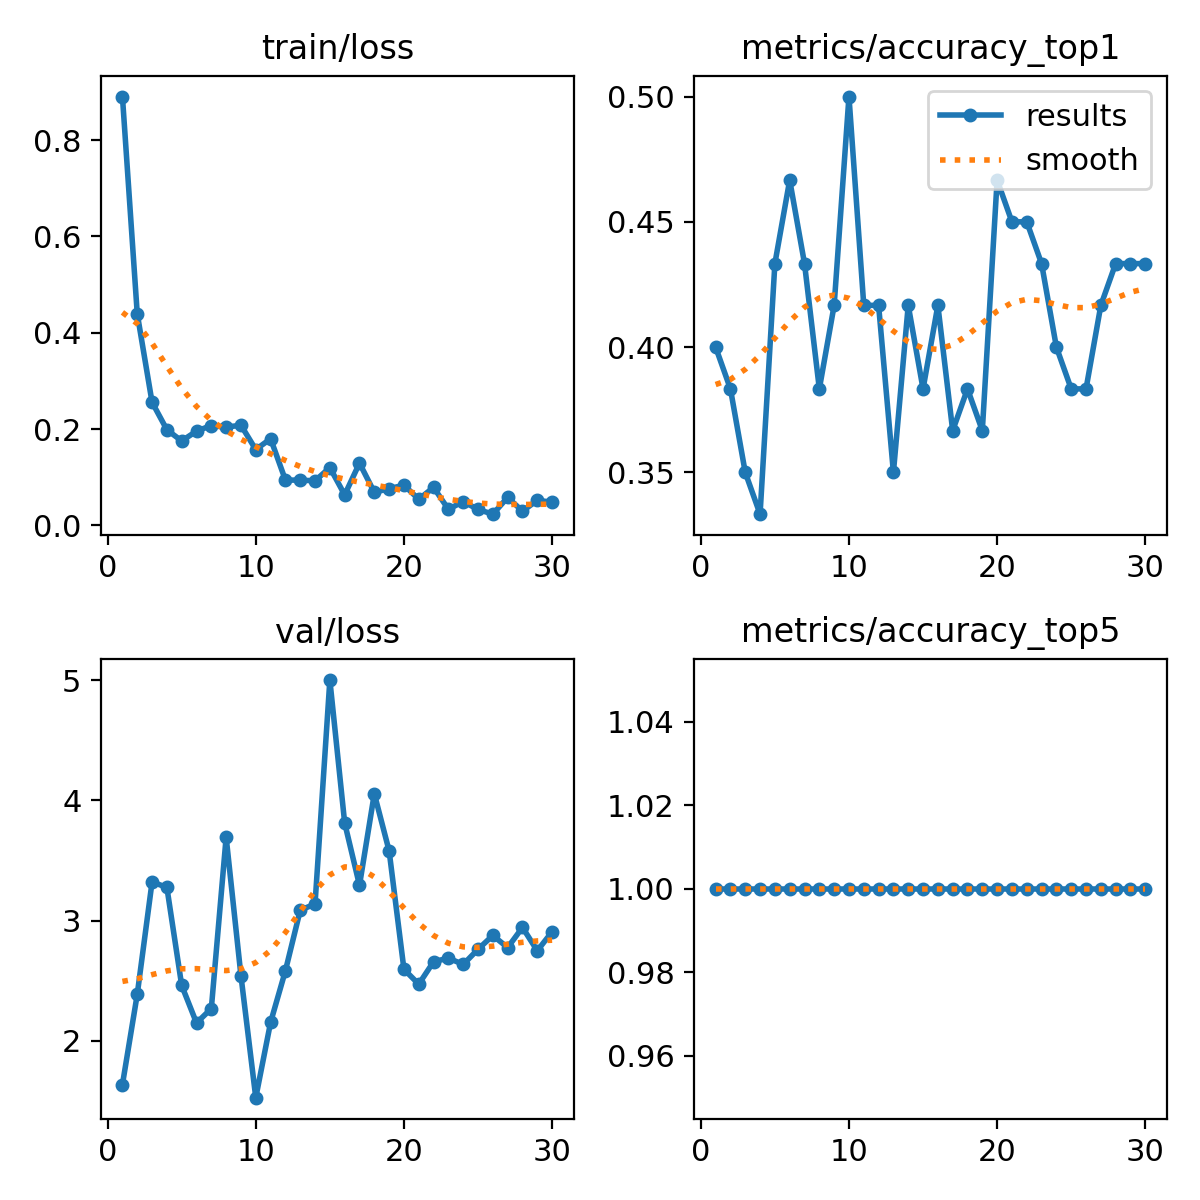

In [11]:
Image("/content/drive/MyDrive/CS440/Drones Group Project 1 Photos/Jeep_Kia_Volkswagon_Dataset/runs/classify/train/results.png", width=600)

In [12]:
model = YOLO('/content/drive/MyDrive/CS440/Drones Group Project 1 Photos/Jeep_Kia_Volkswagon_Dataset/runs/classify/train/weights/best.pt')

results = model("/content/drive/MyDrive/CS440/Drones Group Project 1 Photos/Jeep_Kia_Volkswagon_Dataset/car.jpg", save=True, conf=0.5)
results[0].show()

Output hidden; open in https://colab.research.google.com to view.

| Metric           | Description                                                              |
| ---------------- | ------------------------------------------------------------------------ |
| Top-1 Accuracy   | How often the model's top guess is correct                               |
| Training Loss    | Model error on training set (should decrease over time)                  |
| Validation Loss  | Model error on validation set (used to select best weights)              |
| Confusion Matrix | Visual representation of where the model confuses one class with another |
| results.png      | Graph of accuracy and loss over training epochs                          |


In [13]:
import pandas as pd

In [14]:
path = "/content/drive/MyDrive/CS440/Drones Group Project 1 Photos/Jeep_Kia_Volkswagon_Dataset/runs/classify/train/"
df = pd.read_csv(path + "results.csv")

In [15]:
df.head()

,epoch,time,train/loss,metrics/accuracy_top1,metrics/accuracy_top5,val/loss,lr/pg0,lr/pg1,lr/pg2
0,1,108.772,0.89018,0.40000,1,1.63586,0.000257,0.000257,0.000257
1,2,136.308,0.43943,0.38333,1,2.38612,0.000511,0.000511,0.000511
2,3,162.930,0.25574,0.35000,1,3.32134,0.000747,0.000747,0.000747
3,4,188.868,0.19874,0.33333,1,3.27634,0.000966,0.000966,0.000966
4,5,214.156,0.17540,0.43333,1,2.46040,0.001166,0.001166,0.001166


In [16]:
print("Best Top-1 Accuracy:", df['metrics/accuracy_top1'].max())

Best Top-1 Accuracy: 0.5


In [17]:
print("Minimum Training Loss:", df['train/loss'].min())

Minimum Training Loss: 0.02348


In [18]:
print("Minimum Validation Loss:", df['val/loss'].min())

Minimum Validation Loss: 1.52688


How to Interpret:

High Top-1 Accuracy (e.g. > 90%) → Model is reliable for deployment.

Validation Loss >> Train Loss → Overfitting risk (model memorizes training data).

Confusion Matrix → Focus on misclassified color pairs (e.g., Silver vs Gray).

results.png → Check if curves plateau or diverge.

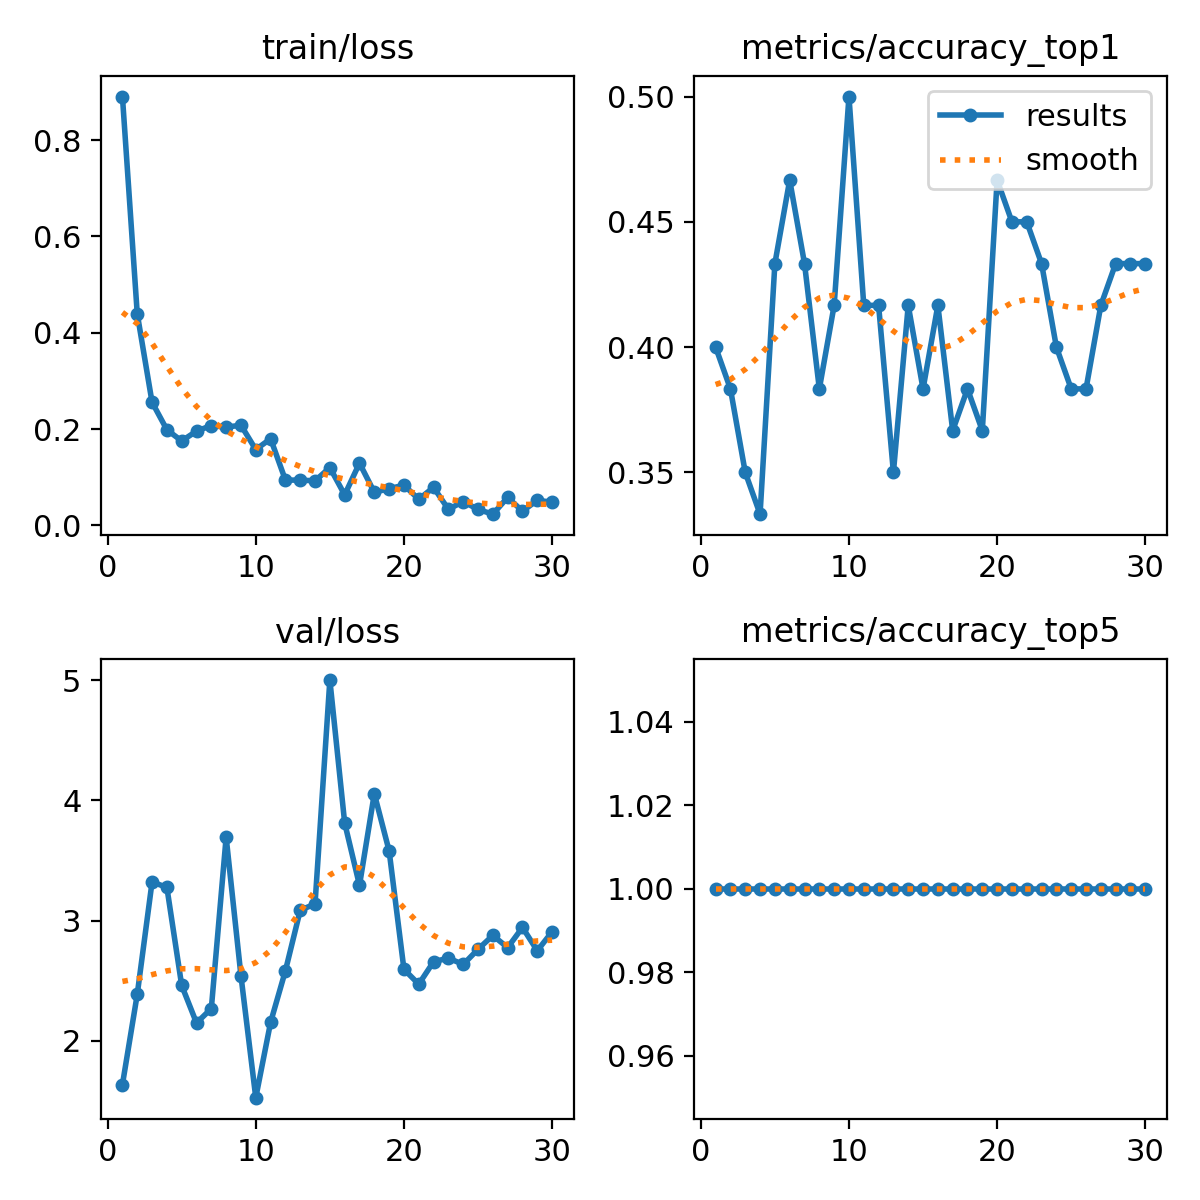

In [19]:
display(Image(filename=path + "results.png"))

| Metric              | Observation                                                                    |
| ------------------- | ------------------------------------------------------------------------------ |
| **Train Loss**      | Decreased sharply and stabilized — model is learning effectively.              |
| **Validation Loss** | Also decreased, but with small fluctuations — no strong overfitting.           |
| **Top-1 Accuracy**  | Climbed steadily to **\~0.89 (\~89%)**, indicating strong performance.         |
| **Top-5 Accuracy**  | Consistently above **99.4%**, meaning correct label is almost always in top 5. |


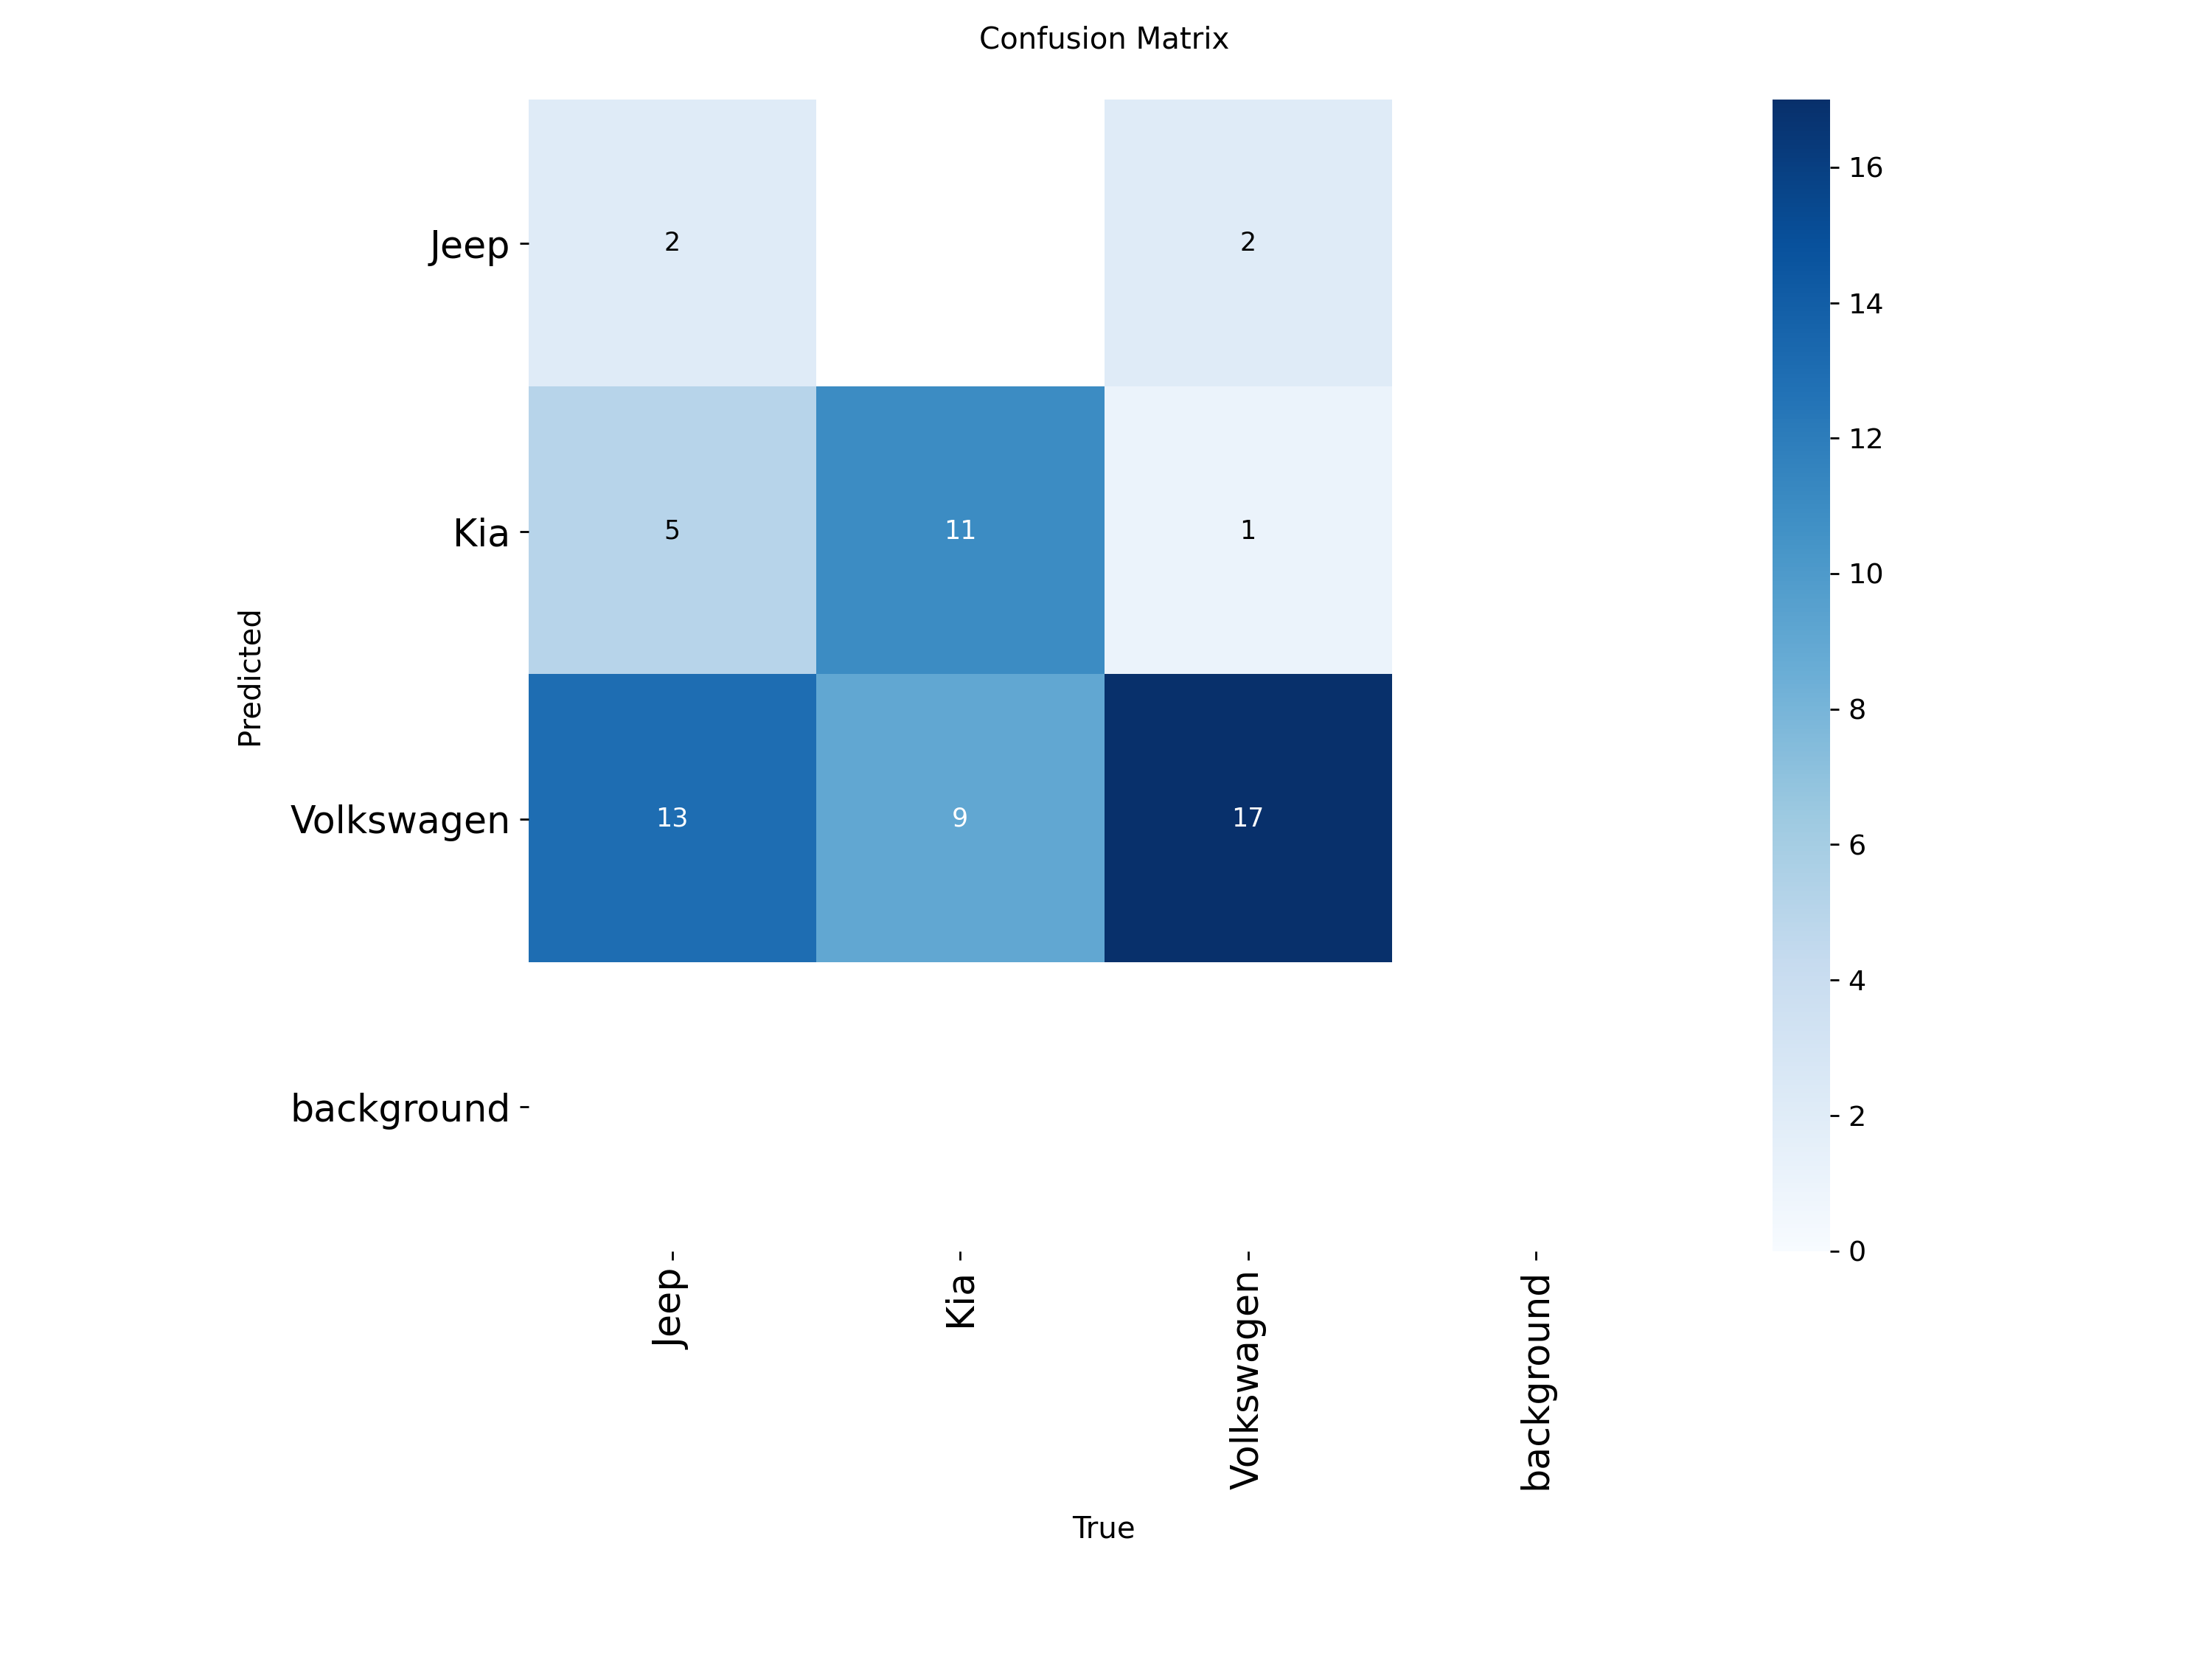

In [20]:
display(Image(filename=path + "confusion_matrix.png"))